# Sensor-Aware Adaptive Linear Trajectory Model for Barrier Coverage

Toy simulation comparing:
1. **Baseline Greedy Placement** — sensors optimised using fixed historical
   intensity lambda_0(l).
2. **Adaptive-Aware Greedy Placement** — sensors optimised assuming targets
   shift toward low-detection trajectories.

Both methods are evaluated under increasing adversarial strength beta.

## Basic configs

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings("ignore")

NOTEBOOK_DIR = os.getcwd()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.4,
})

C_BASELINE = "#0072B2"  
C_ADAPTIVE = "#D55E00"   
C_TRAJ     = "#888888"  
C_SENSOR1  = "#0072B2"
C_SENSOR2  = "#D55E00"

#Representation space C = (alpha, p)
ALPHA_BINS = 72
ALPHA_EDGES = np.linspace(0, np.pi, ALPHA_BINS + 1)
ALPHA_CENTERS = (ALPHA_EDGES[:-1] + ALPHA_EDGES[1:]) / 2
P_BINS = 30
P_MIN, P_MAX = -15.0, 15.0
P_EDGES = np.linspace(P_MIN, P_MAX, P_BINS + 1)
P_CENTERS = (P_EDGES[:-1] + P_EDGES[1:]) / 2

AA, PP = np.meshgrid(ALPHA_CENTERS, P_CENTERS)

d_alpha = ALPHA_CENTERS[1] - ALPHA_CENTERS[0]
d_p     = P_CENTERS[1] - P_CENTERS[0]
d_l     = d_alpha * d_p

#Sensor information
GRID_STEP = 0.5
sensor_x = np.arange(-10.0, 10.0 + GRID_STEP/2, GRID_STEP)
sensor_y = np.arange(-10.0, 10.0 + GRID_STEP/2, GRID_STEP)
SX, SY   = np.meshgrid(sensor_x, sensor_y)
candidate_sensors = np.column_stack((SX.ravel(), SY.ravel()))  # (1681, 2)
M = 5  # sensor number

## Trajectory Data processing & Historical Intensity  lambda_0(l)

In [2]:
#Loading toy tranjectory data
data = np.genfromtxt(
    os.path.join(NOTEBOOK_DIR, "synthetic_trajectories.csv"),
    delimiter=",", skip_header=1, dtype=None, encoding="utf-8"
)

traj_ids = np.array([row[0] for row in data])
slopes   = np.array([row[1] for row in data], dtype=float)
intercepts = np.array([row[2] for row in data], dtype=float)

print("Loaded trajectories (y = m*x + b):")
for tid, m, b in data:
    print(f"  trajectory {tid}:  m={m:6.2f}  b={b:6.2f}")

Loaded trajectories (y = m*x + b):
  trajectory 1:  m=  0.00  b=  0.00
  trajectory 2:  m=  0.05  b=  0.80
  trajectory 3:  m= -0.05  b= -0.80
  trajectory 4:  m=  0.30  b=  1.50
  trajectory 5:  m=  0.60  b= -0.50
  trajectory 6:  m=  1.00  b= -2.00
  trajectory 7:  m= -0.30  b=  1.50
  trajectory 8:  m= -0.60  b= -0.50
  trajectory 9:  m= -1.00  b= -2.00
  trajectory 10:  m=  2.00  b=  0.00


In [3]:

#line: y = m*x + b
#normal form: x*cos(α) + y*sin(α) = p
#using normal (-m, 1) pointing upward-left:
#   cos(α) = -m / sqrt(m²+1)   sin(α) = 1 / sqrt(m²+1)
#   α = atan2(1, -m)  ∈ (0, π)
#   p = b / sqrt(m²+1)
norm_factor = np.sqrt(slopes**2 + 1.0)
alphas = np.arctan2(1.0, -slopes)  # α e (0, π)
ps     = intercepts / norm_factor

alphas = np.where(alphas < 0, alphas + np.pi, alphas)

print(f"\nConverted to representation space (α, p):")
for tid, a, p_ in zip(traj_ids, alphas, ps):
    print(f"  trajectory {tid}:  α={a:.4f} rad  p={p_:.4f} km")
print(f"\nα range: [{alphas.min():.4f}, {alphas.max():.4f}]")
print(f"p range: [{ps.min():.4f}, {ps.max():.4f}]")


Converted to representation space (α, p):
  trajectory 1:  α=1.5708 rad  p=0.0000 km
  trajectory 2:  α=1.6208 rad  p=0.7990 km
  trajectory 3:  α=1.5208 rad  p=-0.7990 km
  trajectory 4:  α=1.8623 rad  p=1.4367 km
  trajectory 5:  α=2.1112 rad  p=-0.4287 km
  trajectory 6:  α=2.3562 rad  p=-1.4142 km
  trajectory 7:  α=1.2793 rad  p=1.4367 km
  trajectory 8:  α=1.0304 rad  p=-0.4287 km
  trajectory 9:  α=0.7854 rad  p=-1.4142 km
  trajectory 10:  α=2.6779 rad  p=0.0000 km

α range: [0.7854, 2.6779]
p range: [-1.4142, 1.4367]


In [4]:
#inside theta

X_MIN, X_MAX, Y_MIN, Y_MAX = -10.0, 10.0, -10.0, 10.0

def line_passes_through_A(alpha, p):
    cos_a, sin_a = np.cos(alpha), np.sin(alpha)
    corners_x = np.array([X_MIN, X_MIN, X_MAX, X_MAX])
    corners_y = np.array([Y_MIN, Y_MAX, Y_MIN, Y_MAX])
    proj = corners_x * cos_a + corners_y * sin_a
    return np.min(proj) - 1e-10 <= p <= np.max(proj) + 1e-10

Theta_mask = np.array([
    line_passes_through_A(a, p) for a, p in zip(AA.ravel(), PP.ravel())
]).reshape(AA.shape)

print(f"Theta covers {Theta_mask.sum()} / {Theta_mask.size} grid cells"
      f" ({100 * Theta_mask.sum() / Theta_mask.size:.1f}%)")

Theta covers 1832 / 2160 grid cells (84.8%)


In [ ]:
#building lambda_0(l) via histogram + gaussian smoothing
from scipy.ndimage import gaussian_filter

hist_counts, _, _ = np.histogram2d(alphas, ps, bins=[ALPHA_EDGES, P_EDGES])
hist_counts = hist_counts.T  #transpose to match (Np, Nα) meshgrid shape

#smoothing with Gaussian filter
lambda_0_raw = gaussian_filter(hist_counts.astype(float), sigma=0.8, truncate=2.0)
lambda_0_raw[~Theta_mask] = 0.0

#normalize to actual number of trajectories
N_traj = len(traj_ids)
LAMBDA_0 = float(N_traj)
lambda_0 = lambda_0_raw / lambda_0_raw.sum() * LAMBDA_0
print(f"N_traj = {N_traj}")
print(f"lambda_0 sum = {lambda_0.sum():.4f}  (target LAMBDA_0 = {LAMBDA_0})")
print(f"lambda_0 shape = {lambda_0.shape}")

N_traj = 10
lambda_0 sum = 10.0000  (target LAMBDA_0 = 10.0)
lambda_0 shape = (30, 72)


In [6]:
def plot_trajectories_physical(ax, slopes, intercepts, sensor_range=10.0, **kw):
    x_vals = np.linspace(-sensor_range, sensor_range, 200)
    for m, b in zip(slopes, intercepts):
        y_vals = m * x_vals + b
        mask = np.abs(y_vals) <= sensor_range
        if mask.sum() > 1:
            ax.plot(x_vals[mask], y_vals[mask], **kw)

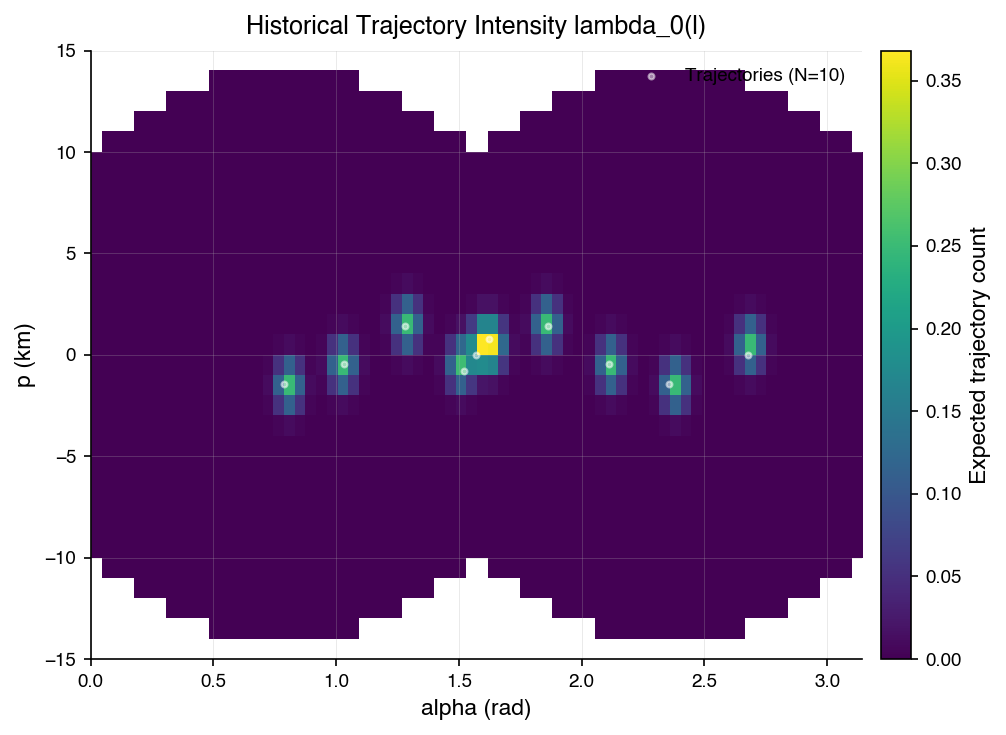

In [7]:
lambda_0_masked = np.ma.masked_where(~Theta_mask, lambda_0)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(lambda_0_masked, extent=[0, np.pi, P_MIN, P_MAX],
               origin="lower", aspect="auto", cmap="viridis")
cb = fig.colorbar(im, ax=ax, label="Expected trajectory count", pad=0.02)
cb.ax.tick_params(labelsize=9)

ax.scatter(alphas, ps, c="white", s=8, alpha=0.5,
           label=f"Trajectories (N={N_traj})", zorder=5)
ax.set_xlabel("alpha (rad)")
ax.set_ylabel("p (km)")
ax.set_title("Historical Trajectory Intensity lambda_0(l)", pad=8)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_DIR, "fig1_lambda0.png"))
plt.show()

## Sensor Detection Model

In [8]:
RHO   = 0.95  
SIGMA_L = 0.15

def gamma_C(l, sensor):
    alpha, p = l
    ax, ay = sensor
    p_proj = ax * np.cos(alpha) + ay * np.sin(alpha)
    return RHO * np.exp(-((p - p_proj) ** 2) / SIGMA_L)

def pi_C(sensors):
    alpha_grid_3d = AA[np.newaxis, :, :]      #(1, Np, Nα)
    p_grid_3d     = PP[np.newaxis, :, :]         #(1, Nα, Np)
    sensors_3d    = sensors[:, np.newaxis, np.newaxis, :]  #(M, 1, 1, 2)
    ax = sensors_3d[..., 0]
    ay = sensors_3d[..., 1]
    p_proj = ax * np.cos(alpha_grid_3d) + ay * np.sin(alpha_grid_3d)
    gamma = RHO * np.exp(-((p_grid_3d - p_proj) ** 2) / SIGMA_L)
    pi = np.prod(1.0 - gamma, axis=0)
    pi[~Theta_mask] = 0.0
    return pi

## Function for determining Adaptive Intensity

In [9]:
def lambda_beta(beta, sensors):
    pi = pi_C(sensors)
    numer = lambda_0 * np.exp(beta * pi)
    denom = (lambda_0 * np.exp(beta * pi)).sum()
    return LAMBDA_0 * numer / denom, pi

def J_beta(beta, sensors):
    lb, pi = lambda_beta(beta, sensors)
    return np.sum(lb * pi * d_l)

def nu_beta(beta, sensors):
    return np.exp(-J_beta(beta, sensors))

## Sensor Placement with Greedy method

In [10]:
def greedy_placement(beta_train):
    chosen = []
    remaining = list(range(len(candidate_sensors)))
    for k in range(M):
        best_J = np.inf
        best_idx = None
        for idx in remaining:
            trial = candidate_sensors[idx]
            trial_set = chosen + [trial]
            j = J_beta(beta_train, np.array(trial_set))
            if j < best_J:
                best_J = j
                best_idx = idx
        chosen.append(candidate_sensors[best_idx])
        remaining.remove(best_idx)
        print(f"  Sensor {k + 1}: ({chosen[-1][0]:5.1f}, {chosen[-1][1]:5.1f})  "
              f"J={best_J:.4f}")
    return np.array(chosen)

### Baseline Greedy(beta=0)

In [11]:
print("Baseline Greedy (beta=0):")
sensors_base = greedy_placement(beta_train=0.0)
print()
print("Final baseline sensor locations:")
print(sensors_base)

Baseline Greedy (beta=0):
  Sensor 1: (  0.0,  -0.5)  J=0.3321
  Sensor 2: (  0.0,   0.5)  J=0.2305
  Sensor 3: (  0.0,   1.5)  J=0.1616
  Sensor 4: (  0.0,  -2.0)  J=0.1048
  Sensor 5: ( -0.5,   2.5)  J=0.0781

Final baseline sensor locations:
[[ 0.  -0.5]
 [ 0.   0.5]
 [ 0.   1.5]
 [ 0.  -2. ]
 [-0.5  2.5]]


NameError: name 'sensors_adapt' is not defined

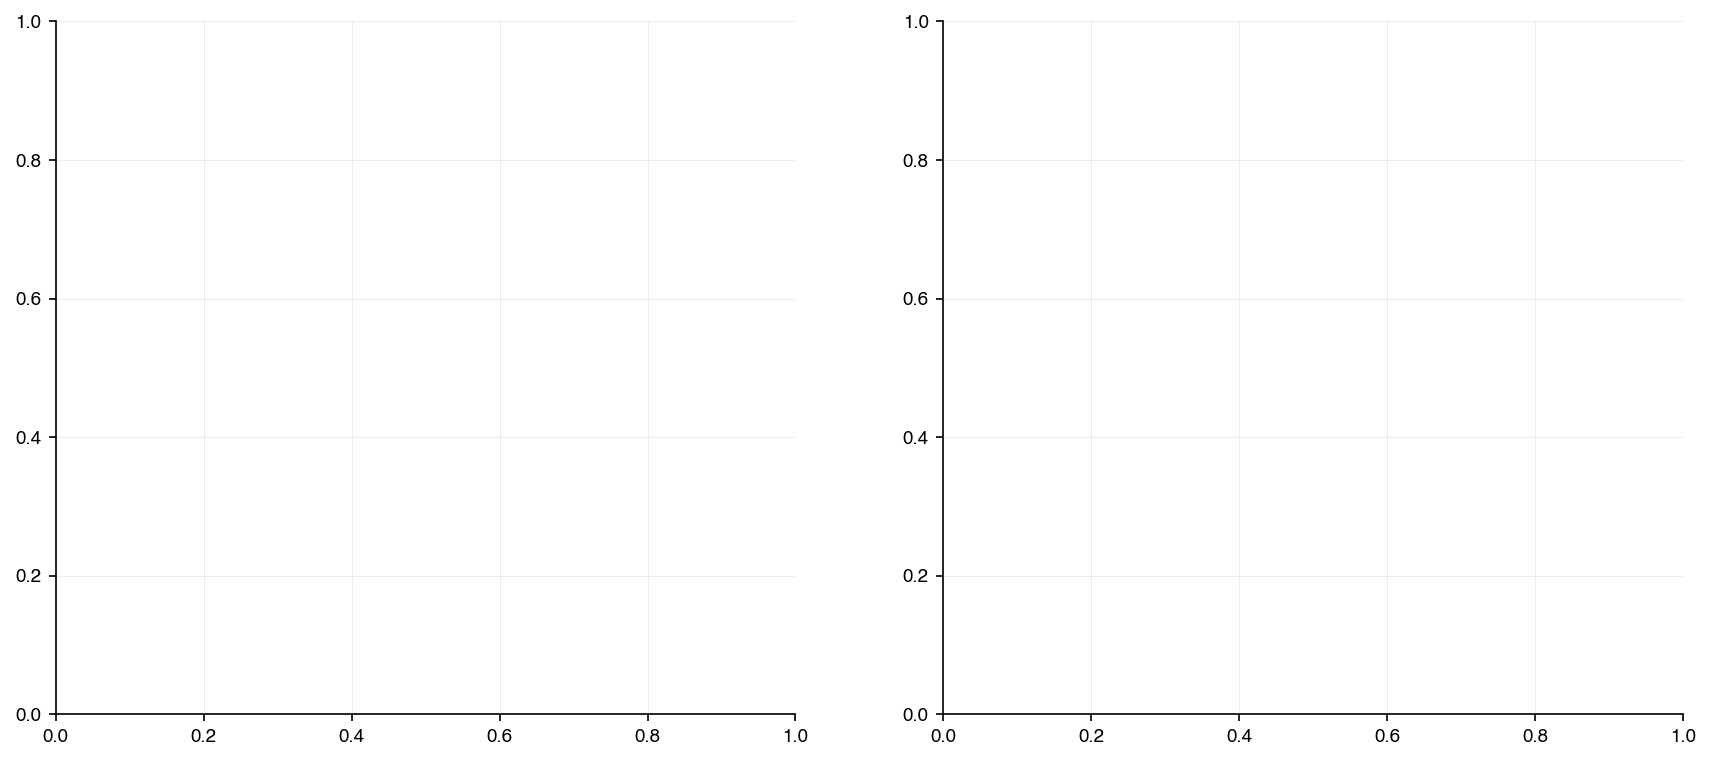

### Adaptive-Aware Greedy(beta_train=3)

In [13]:
print("Adaptive-Aware Greedy (beta_train=3):")
sensors_adapt = greedy_placement(beta_train=3.0)
print()
print("Final adaptive-aware sensor locations:")
print(sensors_adapt)

Adaptive-Aware Greedy (beta_train=3):
  Sensor 1: (  0.0,   0.0)  J=0.4047
  Sensor 2: ( -3.5,   1.0)  J=0.3831
  Sensor 3: (  3.5,   1.0)  J=0.3549
  Sensor 4: ( -2.0,  -1.0)  J=0.3265
  Sensor 5: (  0.0,   2.0)  J=0.3049

Final adaptive-aware sensor locations:
[[ 0.   0. ]
 [-3.5  1. ]
 [ 3.5  1. ]
 [-2.  -1. ]
 [ 0.   2. ]]


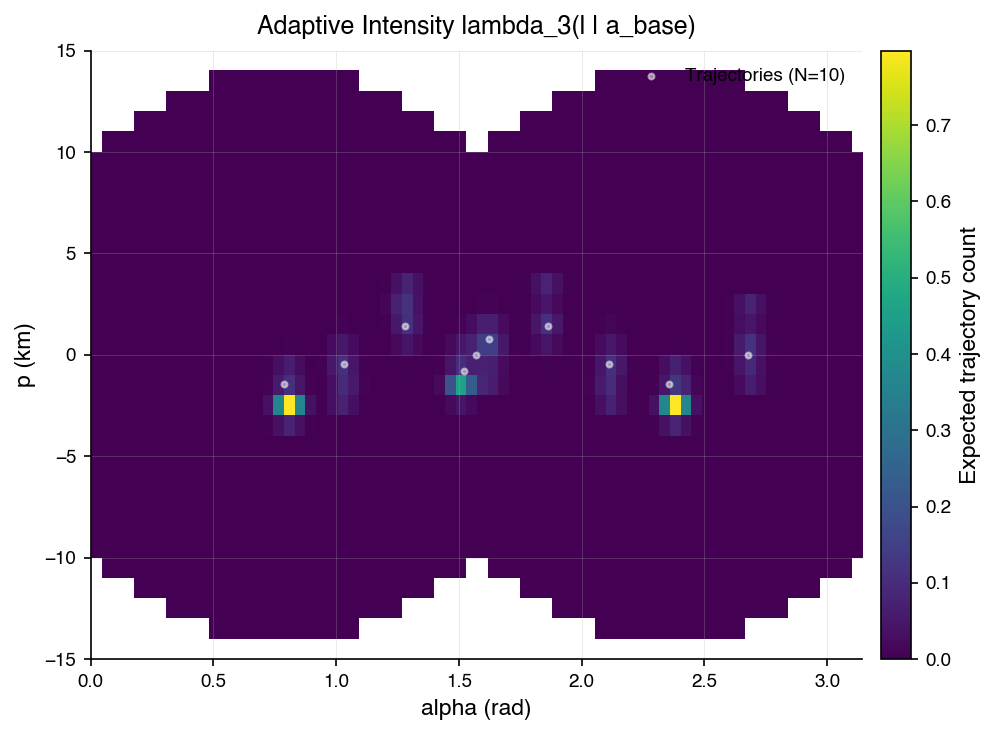

In [14]:
lb_adapt, pi_base = lambda_beta(beta=3.0, sensors=sensors_base)
lb_adapt_masked = np.ma.masked_where(~Theta_mask, lb_adapt)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(lb_adapt_masked, extent=[0, np.pi, P_MIN, P_MAX],
               origin="lower", aspect="auto", cmap="viridis")
cb = fig.colorbar(im, ax=ax, label="Expected trajectory count", pad=0.02)
cb.ax.tick_params(labelsize=9)

ax.scatter(alphas, ps, c="white", s=8, alpha=0.5,
           label=f"Trajectories (N={N_traj})", zorder=5)
ax.set_xlabel("alpha (rad)")
ax.set_ylabel("p (km)")
ax.set_title("Adaptive Intensity lambda_3(l | a_base)", pad=8)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_DIR, "fig3_adaptive_intensity.png"))
plt.show()

### Sensors placement comparison between baseline Greedy and Adaptive sensor Aware Greedy(beta=3)

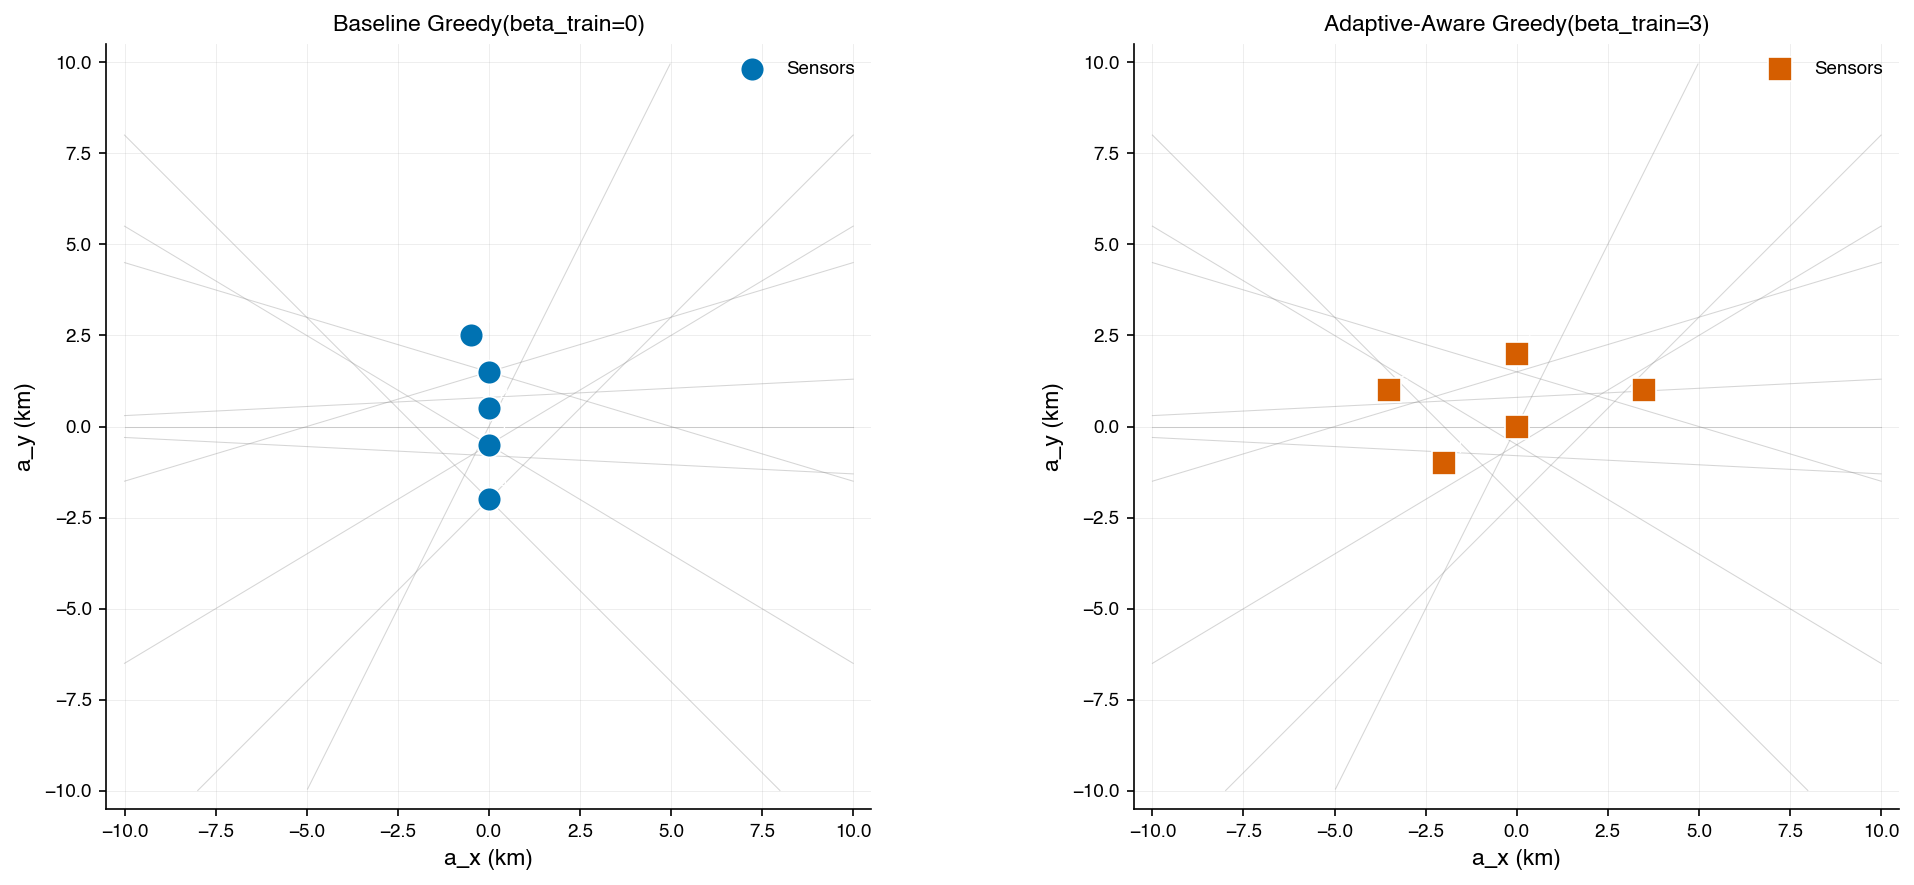

In [17]:
SR = 10.0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, sensors, title, color, marker in [
    (ax1, sensors_base, "Baseline Greedy(beta_train=0)", C_SENSOR1, "o"),
    (ax2, sensors_adapt, "Adaptive-Aware Greedy(beta_train=3)", C_SENSOR2, "s"),
]:
    plot_trajectories_physical(ax, slopes, intercepts, SR,
                                color=C_TRAJ, linewidth=0.5, alpha=0.35)
    ax.scatter(sensors[:, 0], sensors[:, 1],
               marker=marker, s=130, c=color, edgecolors="white", linewidths=0.8,
               label="Sensors", zorder=5)
    for i, (sx, sy) in enumerate(sensors):
        ax.annotate(str(i+1), (sx, sy), textcoords="offset points",
                    xytext=(5, 5), fontsize=7, fontweight="bold",
                    color="white" if color == C_SENSOR2 else "white")
    ax.set_xlabel("a_x (km)")
    ax.set_ylabel("a_y (km)")
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False)
    ax.set_xlim(-SR - 0.5, SR + 0.5)
    ax.set_ylim(-SR - 0.5, SR + 0.5)
    ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_DIR, "fig2_sensor_placement.png"))
plt.show()

## Evaluation under varying beta

In [ ]:
beta_evals = [0.0, 1.0, 3.0, 5.0]
results = []

for method_name, sens in [("Baseline Greedy", sensors_base),
                           ("Adaptive-Aware Greedy", sensors_adapt)]:
    for b in beta_evals:
        j = J_beta(b, sens)
        n = nu_beta(b, sens)
        results.append((method_name, b, j, n))
        print(f"{method_name:25s}  beta={b:.0f}  "
              f"J={j:.4f}  nu={n:.4f}")

Baseline Greedy            beta=0  J=0.0781  nu=0.9248
Baseline Greedy            beta=1  J=0.1171  nu=0.8895
Baseline Greedy            beta=3  J=0.2569  nu=0.7734
Baseline Greedy            beta=5  J=0.3748  nu=0.6874
Adaptive-Aware Greedy      beta=0  J=0.2489  nu=0.7797
Adaptive-Aware Greedy      beta=1  J=0.2694  nu=0.7639
Adaptive-Aware Greedy      beta=3  J=0.3049  nu=0.7372
Adaptive-Aware Greedy      beta=5  J=0.3329  nu=0.7169


Placing sensors for beta_train=0.0 ...
  Sensor 1: (  0.0,  -0.5)  J=0.3321
  Sensor 2: (  0.0,   0.5)  J=0.2305
  Sensor 3: (  0.0,   1.5)  J=0.1616
  Sensor 4: (  0.0,  -2.0)  J=0.1048
  Sensor 5: ( -0.5,   2.5)  J=0.0781
Placing sensors for beta_train=1.0 ...
  Sensor 1: ( -0.5,   0.5)  J=0.3838
  Sensor 2: (  0.0,  -0.5)  J=0.3146
  Sensor 3: ( -0.5,   1.5)  J=0.2507
  Sensor 4: (  0.0,  -2.0)  J=0.1688
  Sensor 5: ( -0.5,   2.5)  J=0.1298
Placing sensors for beta_train=3.0 ...
  Sensor 1: (  0.0,   0.0)  J=0.4047
  Sensor 2: ( -3.5,   1.0)  J=0.3831
  Sensor 3: (  3.5,   1.0)  J=0.3549
  Sensor 4: ( -2.0,  -1.0)  J=0.3265
  Sensor 5: (  0.0,   2.0)  J=0.3049
Placing sensors for beta_train=5.0 ...
  Sensor 1: (  0.0,   0.0)  J=0.4112
  Sensor 2: (  0.0,   2.0)  J=0.3931
  Sensor 3: (  0.5,  -2.0)  J=0.3651
  Sensor 4: ( -2.0,  -1.0)  J=0.3515
  Sensor 5: (  4.0,   1.0)  J=0.3315


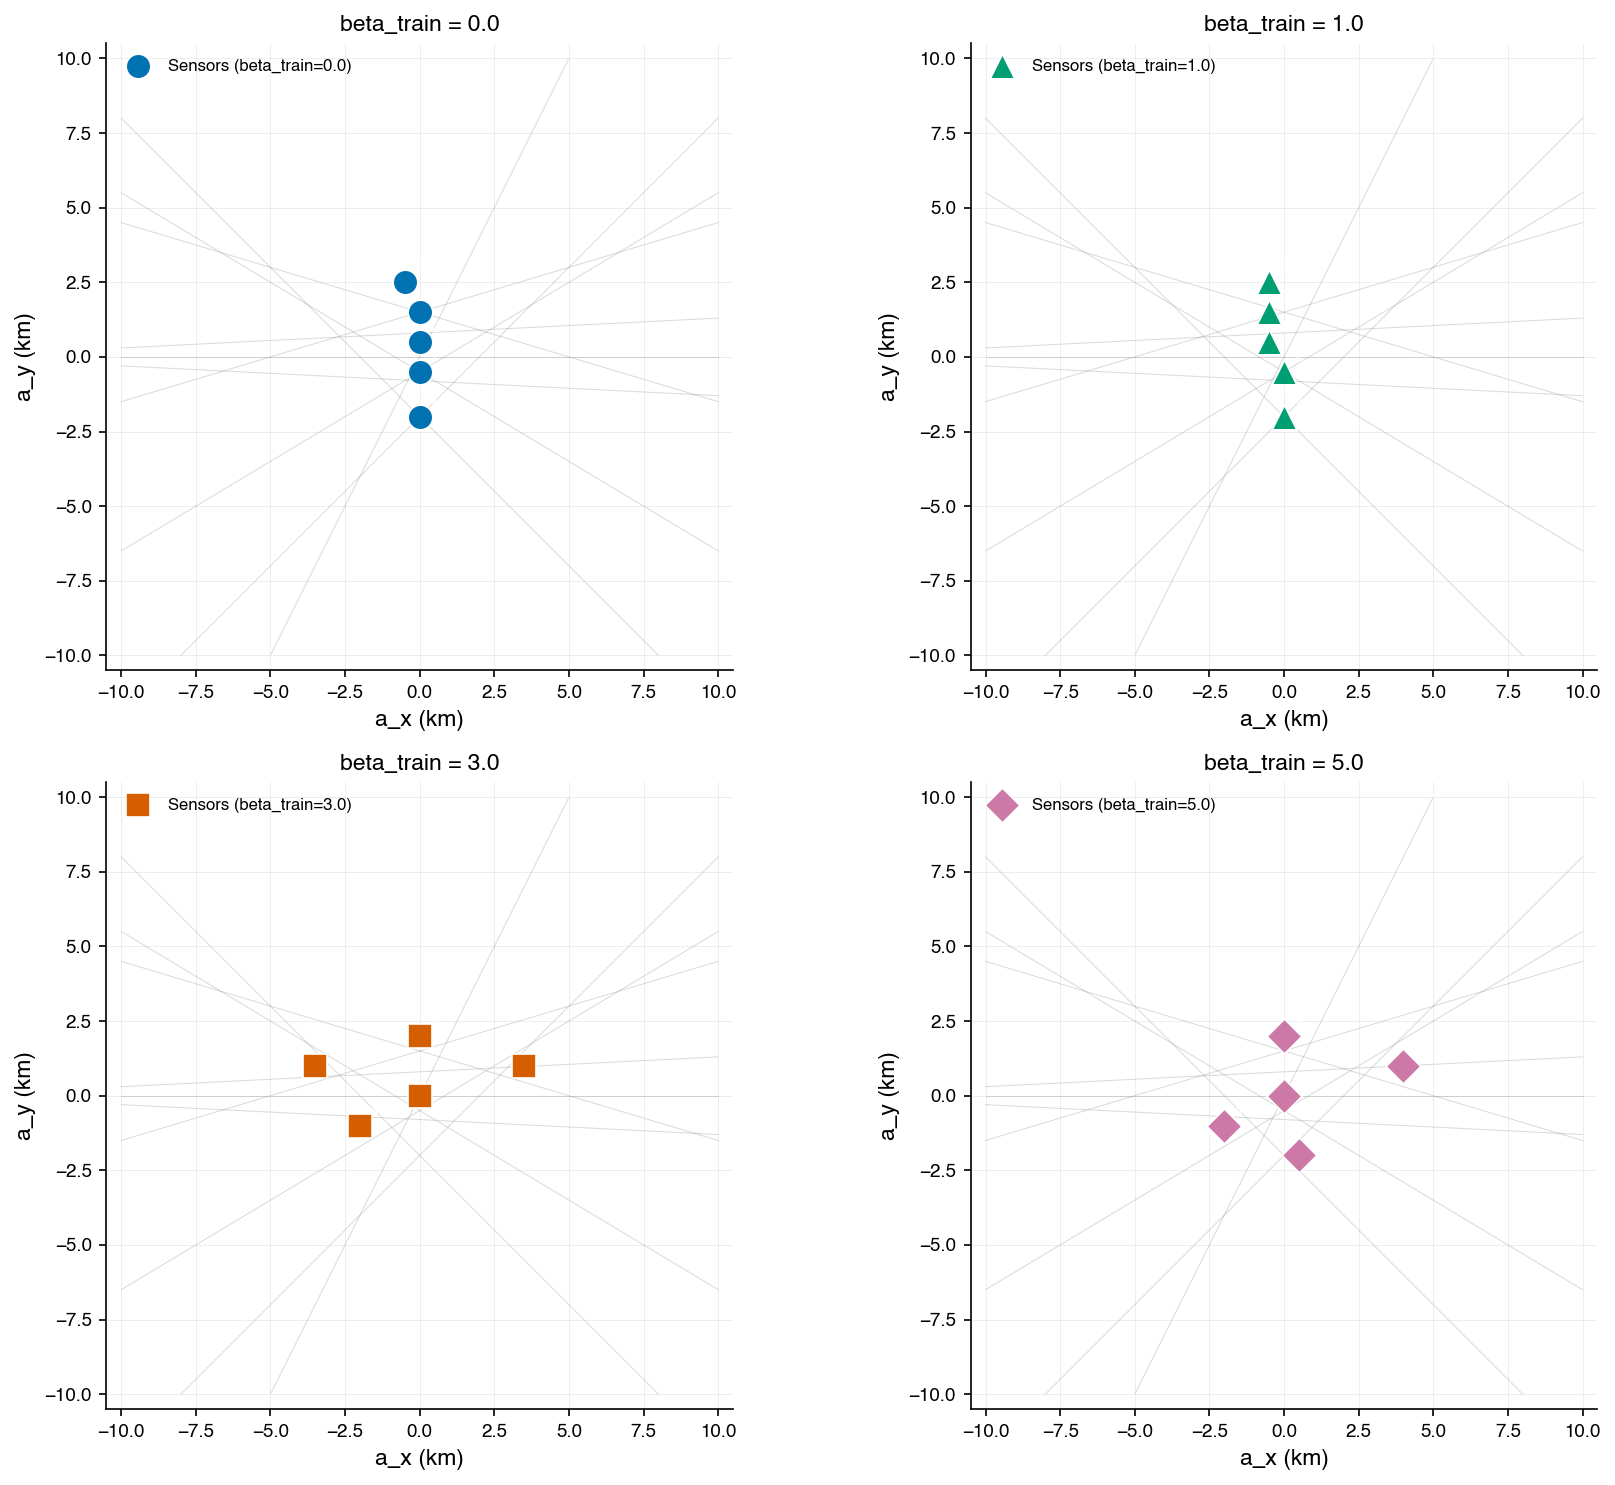

In [15]:
beta_trains = [0.0, 1.0, 3.0, 5.0]
beta_colors = ["#0072B2", "#009E73", "#D55E00", "#CC79A7"]
beta_markers = ["o", "^", "s", "D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

SR = 10.0
for idx, (bt, c, m) in enumerate(zip(beta_trains, beta_colors, beta_markers)):
    ax = axes[idx]
    print(f"Placing sensors for beta_train={bt} ...")
    sens = greedy_placement(beta_train=bt)

    plot_trajectories_physical(ax, slopes, intercepts, SR,
                                color=C_TRAJ, linewidth=0.5, alpha=0.3)
    ax.scatter(sens[:, 0], sens[:, 1],
               marker=m, s=140, c=c, edgecolors="white", linewidths=0.8,
               label=f"Sensors (beta_train={bt})", zorder=5)
    for i, (sx, sy) in enumerate(sens):
        ax.annotate(str(i+1), (sx, sy), textcoords="offset points",
                    xytext=(5, 5), fontsize=7, fontweight="bold", color="white")
    ax.set_xlabel("a_x (km)")
    ax.set_ylabel("a_y (km)")
    ax.set_title(f"beta_train = {bt}", fontsize=11)
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(-SR - 0.5, SR + 0.5)
    ax.set_ylim(-SR - 0.5, SR + 0.5)
    ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_DIR, "fig5_placement_vs_beta.png"))
plt.show()

### Expected missed trajectories J_beta and void probability nu_beta

In [ ]:
print()
header = f"{'Method':25s} " + "".join(f"  beta={b:.0f}  " for b in beta_evals)
sep = "-" * len(header)
print(header)
print(sep)
for method_name, sens in [("Baseline Greedy", sensors_base),
                           ("Adaptive-Aware Greedy", sensors_adapt)]:
    row = f"{method_name:25s}"
    for b in beta_evals:
        j = J_beta(b, sens)
        n = nu_beta(b, sens)
        row += f"  {j:.3f}/{n:.4f}  "
    print(row)


Method                      beta=0    beta=1    beta=3    beta=5  
------------------------------------------------------------------
Baseline Greedy            0.078/0.9248    0.117/0.8895    0.257/0.7734    0.375/0.6874  
Adaptive-Aware Greedy      0.249/0.7797    0.269/0.7639    0.305/0.7372    0.333/0.7169  


## Performance vs Adversarial Strength beta

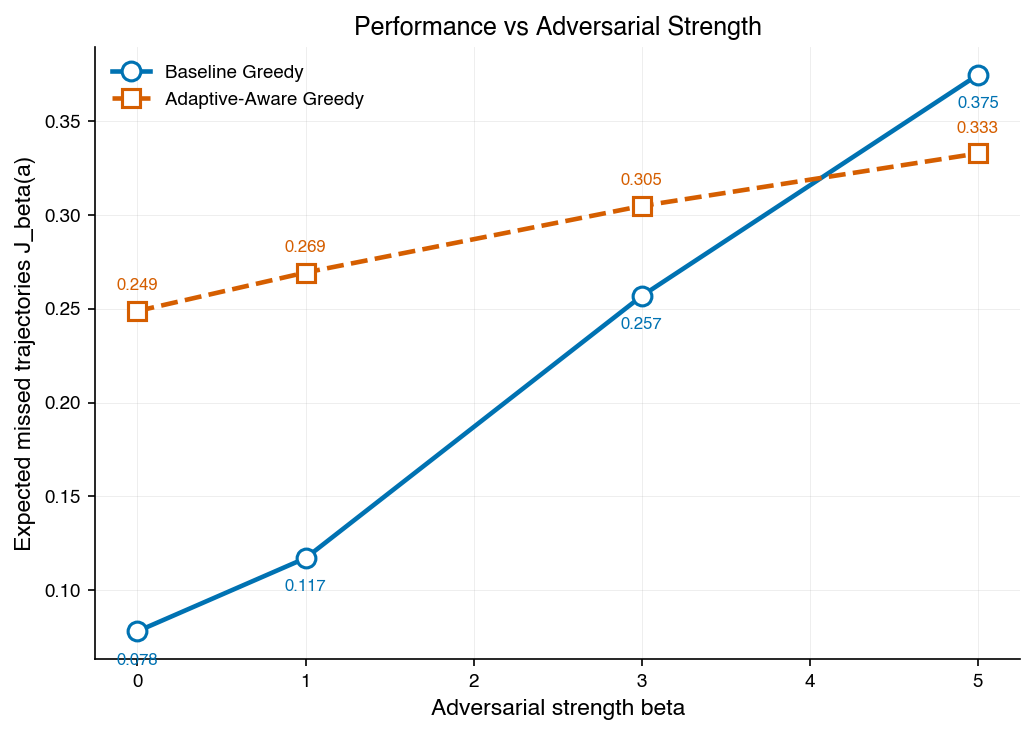

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

j_base = [J_beta(b, sensors_base) for b in beta_evals]
j_adapt = [J_beta(b, sensors_adapt) for b in beta_evals]

ax.plot(beta_evals, j_base, "o-", c=C_BASELINE, linewidth=2.2, markersize=9,
        markerfacecolor="white", markeredgecolor=C_BASELINE, markeredgewidth=1.5,
        label="Baseline Greedy", zorder=3)
ax.plot(beta_evals, j_adapt, "s--", c=C_ADAPTIVE, linewidth=2.2, markersize=9,
        markerfacecolor="white", markeredgecolor=C_ADAPTIVE, markeredgewidth=1.5,
        label="Adaptive-Aware Greedy", zorder=3)

ax.set_xlabel("Adversarial strength beta")
ax.set_ylabel("Expected missed trajectories J_beta(a)")
ax.set_title("Performance vs Adversarial Strength", fontsize=12)
ax.legend(frameon=False)

for i, b in enumerate(beta_evals):
    ax.annotate(f"{j_base[i]:.3f}", (b, j_base[i]),
                textcoords="offset points", xytext=(0, -16), ha="center",
                fontsize=8, color=C_BASELINE)
    ax.annotate(f"{j_adapt[i]:.3f}", (b, j_adapt[i]),
                textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=8, color=C_ADAPTIVE)

fig.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_DIR, "fig4_performance.png"))
plt.show()